<p style="text-align: center; font-size: 28px; font-weight: bold;">CIND 123</p>
<p style="text-align: center; font-size: 24px; font-weight: bold;">Data Analytics: Basic Methods</p>
<p style="text-align: center; font-size: 24px; font-weight: bold;">Assignment 2 (15%)</p>

**Carlos Elizondo**  
**CIND 123 DJ0 W2026, Student number: 500890062**

<p style="text-align: center; font-size: 20px; font-weight: bold;">Instructions</p>

This assignment can be submitted using either Python or R, whichever you prefer.

- **If using R**, you must submit an RMD file with its knitted file (PDF or HTML). To learn more about knitting and R markdown, visit [R Markdown](http://rmarkdown.rstudio.com).
- **If using Python**, you must submit an IPYNB file and its exported PDF/HTML with clearly printed/shown answers.

Failing to submit both files ({RMD + knitted PDF/HTML} OR {IPYNB + PDF/HTML}) will be subject to a 30% mark deduction.

**NOTE:** IF YOU USE `R STUDIO`, YOU SHOULD NEVER HAVE `install.packages` IN YOUR CODE; OTHERWISE, THE `Knit` OPTION WILL RAISE AN ERROR. COMMENT OUT ALL PACKAGE INSTALLATIONS BUT KEEP `library()` CALLS.

**NOTE:** If you answer the questions in R, all your answers should be in R (ignore Python questions). If you answer the questions in Python, all your answers should be in Python (ignore R questions). You are not allowed to switch languages in this assignment.

### Question 1 (20 points)
The battery life of a certain smartphone model follows a normal distribution with a mean of 12 hours and a standard deviation of 2 hours.

### Q1a (5 points)
Calculate the probability that a randomly selected phone lasts more than 14 hours on a full charge.

In [1]:
import scipy.stats as stats
import numpy as np
# Mean is 12hrs and standard deviation is 2hrs following normal distribution
mu = 12
sigma = 2
#looking to solve P(X>14)
#P(X>14)= probability of all the battery lives- probability of 14 or less
prob_gt_14 = 1 - stats.norm.cdf(14, loc=mu, scale=sigma)
print(f"The probability that a randomly selected phone lasts more than 14 hours on a full charge is: {prob_gt_14:.4f}")


The probability that a randomly selected phone lasts more than 14 hours on a full charge is: 0.1587


### Q1b (5 points)

Estimate the battery life of one randomly selected phone from this distribution.

In [2]:
#Estimating the battry life of one randomly selected phone
random_phone = stats.norm.rvs(loc=mu, scale=sigma, size=1)
print(f"The estimated battery life of a randomly selected phone is: {random_phone[0]:.2f} hours")

The estimated battery life of a randomly selected phone is: 15.57 hours


### Q1c (5 points)

Calculate the probability that a phone's battery life is between 10 and 14 hours.

In [3]:
#looking fot the probability of the phone having life between 10 to 14hrs. P(10<=X<=14)
#P(10<=X<=14) = probability of life being 14 or less minus prob of 10 or less leaves you with the in between
prob_between_10_14 = stats.norm.cdf(14, loc=mu, scale=sigma) - stats.norm.cdf(10, loc=mu, scale=sigma)
print(f"The probability that a phone's battery life is between 10 and 14 hours is: {prob_between_10_14:.4f}")

The probability that a phone's battery life is between 10 and 14 hours is: 0.6827


###Q1d (5 points)

Determine the 5th percentile of battery life (i.e., the battery life below which only 5% of phones fall).


In [4]:
#looking for the 5th percentile
percentile_5th = stats.norm.ppf(0.05, mu, sigma)
print(f"Q1d: 5th percentile: {percentile_5th:.2f} hours")

Q1d: 5th percentile: 8.71 hours


### Question 2 (20 points)

Midterm and final grades of some students are given as (87, 72, 80, 91, 85, 69, 40, 34, 61) and (59, 68, 52, 62, 78, 70, 35, 28, 45). Set variables `midterm` and `final` respectively.

In [5]:
#setting the variables, Midterm is the independent variable and final is the dependent variable
midterm= np.array([87, 72, 80, 91, 85, 69, 40, 34, 61]).reshape(-1,1)
final= np.array([59, 68, 52, 62, 78, 70, 35, 28, 45])

### Q2a (5 points)

Find the least-squares line relating the final to the midterm.

Does the assumption of a linear relationship appear to be reasonable in this case? Give reasons to your answer as a comment.

In [6]:
#code
#libraries
import numpy as np
from sklearn.linear_model import LinearRegression

#building the model
model= LinearRegression()
model.fit(midterm, final)
#get the coefficients
intercept = model.intercept_
slope=model.coef_[0]

print(f"Least-squares line: y = {intercept:.2f} + {slope:.2f} * Midterm")
print(f"Intercept(b0): {intercept:.2f}")
print(f"Slope(b1): {slope:.2f}")

Least-squares line: y = 9.58 + 0.66 * Midterm
Intercept(b0): 9.58
Slope(b1): 0.66


**Comment**:
Yes, the assumption of linear relationship appears reasonable in this case. The slope, 0.66, shows there is a positive correlation between the midterm exam and the final exam mark. As students do better on the midterm their marks improve for the final exam.

### Q2b (5 points)

Plot the `final` as a function of the `midterm` using a scatterplot and graph the least-square line in red color on the same plot.

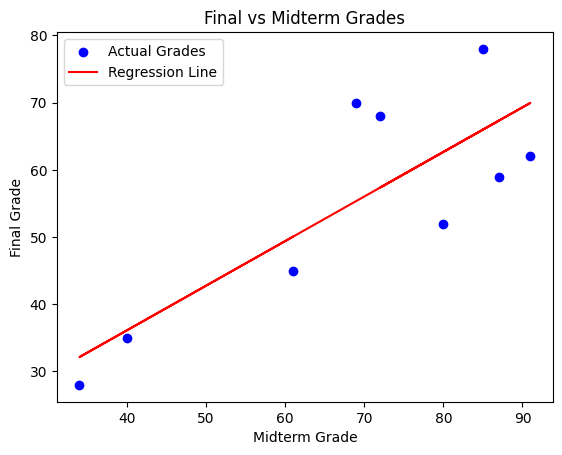

In [7]:
import matplotlib.pyplot as plt
plt.scatter(midterm, final, color='blue', label='Actual Grades')
plt.plot(midterm, model.predict(midterm), color='red', label='Regression Line')
plt.xlabel('Midterm Grade')
plt.ylabel('Final Grade')
plt.title('Final vs Midterm Grades')
plt.legend()
plt.savefig('grades_regression.png')

### Q2c (5 points)

Use the regression line to predict the final grades when the midterm grades are 82 and 32.

In [8]:
# Q2c: Predictions for 82 and 32
test_grades = np.array([82, 32]).reshape(-1, 1)
predictions = model.predict(test_grades)
print(f"Q2c: Predicted final for 82: {predictions[0]:.2f}")
print(f"Q2c: Predicted final for 32: {predictions[1]:.2f}")

Q2c: Predicted final for 82: 64.00
Q2c: Predicted final for 32: 30.82


### Question 3 (40 points)

This question makes use of package `plm` in `R`. Please load Crime dataset as follows:

In [9]:
# Crime = read.csv("crime.csv")
#loading libraries incase we need them during assignment
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
#loading the dataset
crime=pd.read_csv("/content/sample_data/crime.csv")

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In Python, you can load the `crime.csv` file attached to the assignment.

### Q3a (5 points)

Display the first 7 rows of `crime` data and display the names of all the variables, the number of variables, then display a descriptive summary of each variable.

In [11]:
#Displaying first 7 rows, variable names, count and summary
print("first 7 rows:")
print(crime.head(7))
print("\nVariable names:",crime.columns.tolist())
print("Number of variables:",len(crime.columns))
print("\nDescriptive summary of each variable:")
print(crime.describe())

first 7 rows:
   Unnamed: 0  county  year    crmrte    prbarr   prbconv   prbpris  avgsen  \
0           1       1    81  0.039885  0.289696  0.402062  0.472222    5.61   
1           2       1    82  0.038345  0.338111  0.433005  0.506993    5.59   
2           3       1    83  0.030305  0.330449  0.525703  0.479705    5.80   
3           4       1    84  0.034726  0.362525  0.604706  0.520104    6.89   
4           5       1    85  0.036573  0.325395  0.578723  0.497059    6.55   
5           6       1    86  0.034752  0.326062  0.512324  0.439863    6.90   
6           7       1    87  0.035604  0.298270  0.527596  0.436170    6.71   

      polpc   density  ...     lwfir     lwser     lwmfg     lwfed     lwsta  \
0  0.001787  2.307159  ...  5.607452  5.374044  5.434246  6.014619  5.464848   
1  0.001767  2.330254  ...  5.706707  5.444911  5.482013  6.039540  5.536862   
2  0.001836  2.341801  ...  5.736475  5.481292  5.597310  6.084157  5.522900   
3  0.001886  2.346420  ...  5.858

### Q3b (5 points)

Calculate the mean, variance and median of the probability of conviction (`prbconv`) by omitting the missing values, if any.

In [12]:
#Checking for missing values
# Check for standard missing values (NaN)
print(f"Standard missing values in 'prbconv': {crime['prbconv'].isnull().sum()}")
#Check for 'hidden' missing values (like empty strings or common placeholders)
# I will convert to string, remove spaces, and lowercase to catch 'NA', 'n/a', ' ', and or 'missing'.
placeholders = ['unknown', 'n/a', 'na', '', ' ','missing']
hidden_missing = crime['prbconv'].astype(str).str.lower().str.strip().isin(placeholders).sum()
print(f"Hidden missing value placeholders in 'prbconv': {hidden_missing}")

# Even though I didn't find any missing values, I will use .dropna()just incase.
prbconv_clean = crime['prbconv'].dropna()

mean_val = prbconv_clean.mean()
var_val = prbconv_clean.var()
median_val = prbconv_clean.median()

print(f"\nMean: {mean_val:.4f}")
print(f"Variance: {var_val:.4f}")
print(f"Median: {median_val:.4f}")

Standard missing values in 'prbconv': 0
Hidden missing value placeholders in 'prbconv': 0

Mean: 0.6886
Variance: 2.8573
Median: 0.4744


### Q3c (5 points)</p>

Use `lpolpc` (log-police per capita) and `smsa` variables to build a linear regression model to predict probability of conviction (`prbconv`). And, compare with another linear regression model that uses `polpc` (police per capita) and `smsa`.

In [13]:
import statsmodels.api as sm
#Changing 'smsa' to numeric (1 for yes, 0 for no)
crime['smsa_numeric'] = crime['smsa'].map({'yes': 1, 'no': 0})
#Building Model 1 (using lpolpc)
X1 = sm.add_constant(crime[['lpolpc', 'smsa_numeric']])
model1 = sm.OLS(crime['prbconv'], X1).fit()
#Making Model 2 (using polpc)
X2 = sm.add_constant(crime[['polpc', 'smsa_numeric']])
model2 = sm.OLS(crime['prbconv'], X2).fit()
#Compare Results
print(f"Model 1 (lpolpc) R-squared: {model1.rsquared:.4f}")
print(f"Model 2 (polpc) R-squared: {model2.rsquared:.4f}")

# Display full summary for Models to look at coefficient and intercepts(the better model)
print("Model 1 Summary:", model1.summary())
print("Model 2 Summary:", model2.summary())

Model 1 (lpolpc) R-squared: 0.1418
Model 2 (polpc) R-squared: 0.2078
Model 1 Summary:                             OLS Regression Results                            
Dep. Variable:                prbconv   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     51.80
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           1.52e-21
Time:                        23:25:29   Log-Likelihood:                -1176.0
No. Observations:                 630   AIC:                             2358.
Df Residuals:                     627   BIC:                             2371.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

In [14]:
# Function to format and print the equation
def print_equation(model, model_name, feature_name):
    b0 = model.params['const']
    b1 = model.params[feature_name]
    b2 = model.params['smsa_numeric']

    print(f"--- {model_name} Equation ---")
    print(f"prbconv = {b0:.4f} + ({b1:.4f} * {feature_name}) + ({b2:.4f} * smsa)")
    print("-" * 30)

# Display equations for both models
print_equation(model1, "Model 1", "lpolpc")
print_equation(model2, "Model 2", "polpc")

--- Model 1 Equation ---
prbconv = 8.5788 + (1.2049 * lpolpc) + (-0.7827 * smsa)
------------------------------
--- Model 2 Equation ---
prbconv = 0.1944 + (278.5240 * polpc) + (-0.4466 * smsa)
------------------------------


How can you draw a conclusion from the results of part `Q3c`? (Note: Full marks requires comment on the predictors)

Model 2 (using polpc) has a higher R-squared value of 0.2078 compared to model 1 (0.1418). This means that the raw police data explains about 20% of the variance in the dependent variable while the log accounts for 14%

The police per capita both have a positive coefficient indicating a positive correlation. meaning more police present leads to an increase in probability of conviction. The p value for both models is 0.000 meaning that this feature is statistically significant.

The metropolitan area (smsa) both coefficients are negative indicating that smsa reduces the probability of a conviction. The p-value in model 1 is 0.000 and in model 2 is 0.035 which is still below the standard of 0.05 meaning it is also statistically significant.

# <p style="font-size: 20px; font-weight: bold;">Q3d (5 points)</p>

Based on the output of your model, predict the output for different factors of `smsa` when `polpc` is set to 0.0025. Use both the `predict` function and manual intercept and slope equations and compare the results.

In [15]:
#smsa has two possibilities, yes or no, we need to look into both scenarios
# Values for prediction
polpc_val = 0.0025

# 1. Manual Calculation using Model 2 Params
b0 = model2.params['const']
b1 = model2.params['polpc']
b2 = model2.params['smsa_numeric']

# Manual: smsa = 0 (no)
pred_manual_no = b0 + (b1 * polpc_val) + (b2 * 0)
# Manual: smsa = 1 (yes)
pred_manual_yes = b0 + (b1 * polpc_val) + (b2 * 1)

# 2. Using the .predict() function
# We must provide a DataFrame with the same structure as X2
test_data = pd.DataFrame({
    'const': [1, 1],
    'polpc': [polpc_val, polpc_val],
    'smsa_numeric': [0, 1]
})
pred_function = model2.predict(test_data)

print(f"Manual Prediction (SMSA No): {pred_manual_no:.4f}")
print(f"Manual Prediction (SMSA Yes): {pred_manual_yes:.4f}")
print(f"Function Prediction (SMSA No): {pred_function[0]:.4f}")
print(f"Function Prediction (SMSA Yes): {pred_function[1]:.4f}")

Manual Prediction (SMSA No): 0.8907
Manual Prediction (SMSA Yes): 0.4442
Function Prediction (SMSA No): 0.8907
Function Prediction (SMSA Yes): 0.4442


The results are identical for the manual prediction and the function prediction.This is because the predict function uses the same underlying linear equation: y = b0 + b1x1 + b2x2 which in math is represented as Y= m1x1+m2x2+b

### Q3e (10 points)

Find Pearson correlation between probability of prison sentence `prbpris` and tax per capita `taxpc`; and also Pearson correlation between probability of conviction `prbconv` and probability of arrest `prbarr`.

In [16]:
from scipy import stats

# Finding correlation between prbpris (prison sentence) and taxpc (tax per capita)
corr_pris_tax, p_val_pris_tax = stats.pearsonr(crime['prbpris'], crime['taxpc'])

# Finding correlation between prbconv (conviction) and prbarr (arrest)
corr_conv_arr, p_val_conv_arr = stats.pearsonr(crime['prbconv'], crime['prbarr'])

print(f"Prison vs Tax: Correlation = {corr_pris_tax:.4f}, P-value = {p_val_pris_tax:.4f}")
print(f"Conviction vs Arrest: Correlation = {corr_conv_arr:.4f}, P-value = {p_val_conv_arr:.4f}")

Prison vs Tax: Correlation = -0.1121, P-value = 0.0049
Conviction vs Arrest: Correlation = 0.0356, P-value = 0.3728


What conclusions can you draw after using `cor.test`? Write your reasons as comments.

Prison sentence and tax have a negative correlation of-0.1121 with a p-value of 0.0049. Since p-value is below 0.05 it is statistically significant. As per tax capita increases the probability of prison sentence tends to decrese slightly.

The correlation between conviction and arrest is 0.0356 and a p value of 0.3728. Since the p-value is bigger than 0.05 it is not statistically significant. There is not enough evidence to say probability of arrest and conviction are linearly related in this dataset.

### Q3f (10 points)

Display the correlation matrix of the variables: `prbconv`, `prbpris`, `density`, `polpc`.

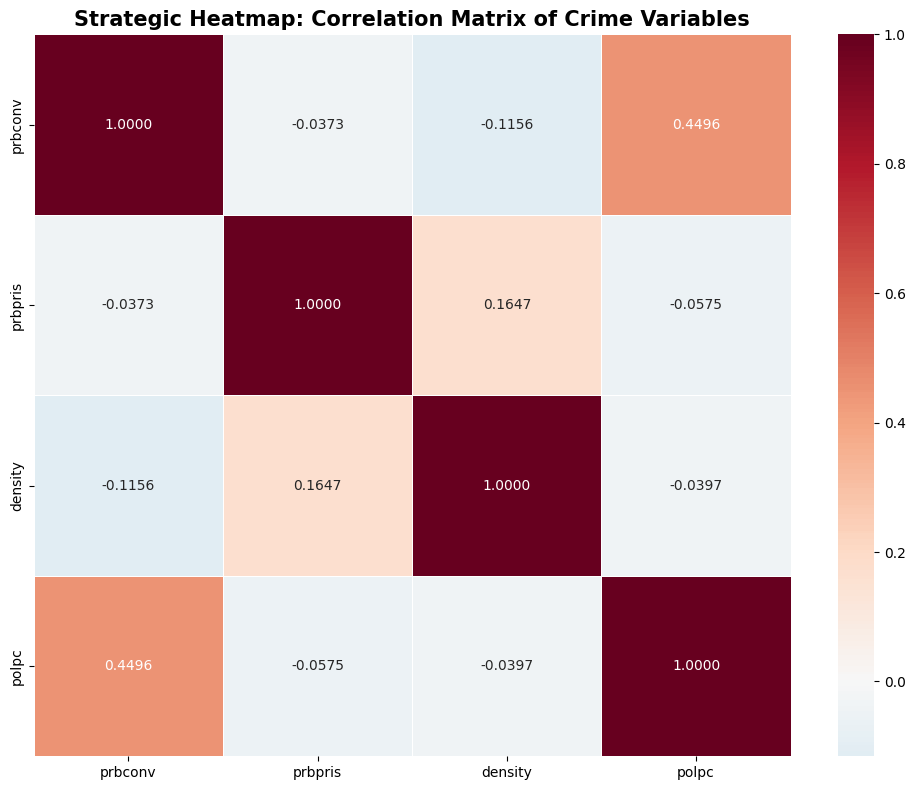

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting the variables requested in Q3f
selected_vars = ['prbconv', 'prbpris', 'density', 'polpc']
corr_matrix = crime[selected_vars].corr()

# Plotting the heatmap following your strategic style
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, annot_kws={"size": 10}, cmap='RdBu_r',center=0, fmt='.4f', linewidths=0.5)

plt.title('Strategic Heatmap: Correlation Matrix of Crime Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('crime_correlation_heatmap.png')

Write what conclusion you can draw, as comments.

There is a moderate positive correlation between polpc and prbconv at around 0.45, meaning as there are more police per capita the probability of a conviction increases.
The next correlation to take note on is between density and prison sentence, the correlation is 0.16 showing a weak positive correlation.
The remaining correlations between the features are all very weak in comparison and negatively correlated.

### Question 4 (20 points)</p>

Many times in data analysis, we need a method that relies on repeated random sampling to obtain numerical results. The underlying concept is to use randomness to solve problems. In fact, this is a mathematical technique, which is used to estimate the possible outcomes of an uncertain event and is called the `Monte Carlo` Method.

Consider that we roll a die 10 times and want to know the probability of getting more than 3 times of even numbers. This is a problem for the Binomial distribution, but suppose we don’t know anything about Binomial distribution. We can easily solve this problem with a simulation or random number generation, called Monte Carlo Simulation.


### Q4a (5 points)

The Monte Carlo Method uses random numbers to simulate some process. Here, the process is rolling a die 20 times. Assume the die is fair. What is the probability of success of getting an even number in rolling the die once?

In [18]:
#The probability of rolling an even number once is 3/6 = 0.5
p_success = 0.5
print(f"Probability of success on one roll: {p_success}")

Probability of success on one roll: 0.5


### Q4b (5 points)</p>

Define a `function` named `one_trial`, that simulates a single round of rolling a die 20 times and returns true if the number of even numbers is > 5.

In [19]:
import numpy as np
def one_trial():
# Rolling a 6-sided die 20 times (random integers 1 through 6)
    rolls = np.random.randint(1, 7, size=20)
# to keep count ofhow many are even (a number is even if remainder when divided by 2 is 0)
    even_count = np.sum(rolls % 2 == 0)
# Return True if the count of even numbers is > 5
    return even_count > 5

### Q4c (5 points)

Repeat the function `one_trial` for $N = 100,000$ times and sum up the outcomes and store the result in a variable named `desired_output`. Compute the probability of getting more than 5 times of even numbers by using relative frequency.


In [20]:
N = 100000
# Run the trial 100,000 times and store results (True/False)
results = [one_trial() for _ in range(N)]

# Summing the list treats True as 1 and False as 0
desired_output = sum(results)

# Calculate probability
mc_probability = desired_output / N

print(f"Number of successful trials: {desired_output}")
print(f"Monte Carlo Estimated Probability: {mc_probability:.4f}")

Number of successful trials: 97925
Monte Carlo Estimated Probability: 0.9792


### Q4d (5 points)
Use the Binomial formula you learned before to calculate such probability and Compare it with the probability value obtained in part (c).

In [21]:
from scipy.stats import binom
# Theoretical prob of 5 or fewer
prob_5_or_less = binom.cdf(5, 20, 0.5)
# Theoretical prob of more than 5
theoretical_prob = 1 - prob_5_or_less
print(f"Mathematical Value: {theoretical_prob:.4f}")

Mathematical Value: 0.9793


The probability of the monte carlo and the binomial formula are almost identical with a difference of 0.0001. This shows that the experimental probability does in fact equal the theoretical probability especially with larger number of trials.

In [22]:
#extra practice
def run_monte_carlo_sim(num_trials=100000):
    """Runs the simulation once and returns the estimated probability."""
    desired_output = sum(one_trial() for _ in range(num_trials))
    return desired_output / num_trials

# 1. Call the function 50 times and store in a list (vector) called Prob
Prob = [run_monte_carlo_sim() for _ in range(50)]

# 2. Take the mean of the Prob vector
final_refined_prob = np.mean(Prob)

print(f"Mean Probability over 50 simulation runs: {final_refined_prob:.6f}")
print(f"Standard Deviation of Results: {np.std(Prob):.6f}")

Mean Probability over 50 simulation runs: 0.979291
Standard Deviation of Results: 0.000429


Congratulations! You have completed the first run of the Monte Carlo simulation.

If there is further interest, put all the above logic in a function, call it at least 50 times, store the results in a vector called Prob, and, to be more accurate, take the mean of the Prob vector. (optional)

**End of Assignment**